In [152]:
!pip install seaborn scikit-learn mlflow python-dotenv

In [4]:
!pwd

/home/tellowit/HSE/MLOPS/notebooks


In [5]:
os.chdir("..")

In [6]:
!pwd

/home/tellowit/HSE/MLOPS


In [9]:
import os
import pandas as pd
import json
from collections import Counter
from urllib.parse import urlparse

In [10]:
import mlflow

In [11]:
from ml_product_categorizer.scripts.categorizer import find_closest_category
from ml_product_categorizer.scripts.preprocessing import (
    extract_keywords,
    flatten_categories,
    keywords_cleaner,
    slugify_categories,
)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

In [12]:
with open("./data/labeled_dataset/0000.json", "r", encoding="utf-8") as file:
    d = json.load(file)

In [13]:
d

{'id': 10,
 'result': [{'id': 'Sr8ZnkYdP1',
   'type': 'taxonomy',
   'value': {'taxonomy': [['Мебель', 'Мебель для хранения']]},
   'origin': 'manual',
   'to_name': 'url',
   'from_name': 'taxonomy'},
  {'id': 'p_lQSG3ayo',
   'type': 'textarea',
   'value': {'text': ['https://ufa.bestmebelshop.ru/upload/resize_cache/iblock/fa2/1000_581_1cb3ed90bb4b099ee9292aa8dda3584d7/fa279320905d6a9ea16eeba18f66d4c2.jpg']},
   'origin': 'manual',
   'to_name': 'url',
   'from_name': 'picture_url'},
  {'id': 'iFwOSyZB6u',
   'type': 'textarea',
   'value': {'text': ['Прихожая угловая Тауз 3 BMS поможет вам рационально организовать пространство прихожей. Модульная композиция включает в себя открытую навесную вешалку с зеркалом и двухъярусной секцией под головные уборы и дополненную полками распашную тумбу для обуви. Изготовленная из отдельных вертикальных планок, вешалка выглядит легкой, а скругленные углы делают пользование комфортным и безопасным. Купить прихожую угловую Тауз 3 BMS вы сможете в на

In [14]:
d["task"]["data"]["url"]

'https://ufa.bestmebelshop.ru/catalog/prikhozhie/prikhozhaya-uglovaya-tauz-3-bms/'

In [15]:
d["result"]

[{'id': 'Sr8ZnkYdP1',
  'type': 'taxonomy',
  'value': {'taxonomy': [['Мебель', 'Мебель для хранения']]},
  'origin': 'manual',
  'to_name': 'url',
  'from_name': 'taxonomy'},
 {'id': 'p_lQSG3ayo',
  'type': 'textarea',
  'value': {'text': ['https://ufa.bestmebelshop.ru/upload/resize_cache/iblock/fa2/1000_581_1cb3ed90bb4b099ee9292aa8dda3584d7/fa279320905d6a9ea16eeba18f66d4c2.jpg']},
  'origin': 'manual',
  'to_name': 'url',
  'from_name': 'picture_url'},
 {'id': 'iFwOSyZB6u',
  'type': 'textarea',
  'value': {'text': ['Прихожая угловая Тауз 3 BMS поможет вам рационально организовать пространство прихожей. Модульная композиция включает в себя открытую навесную вешалку с зеркалом и двухъярусной секцией под головные уборы и дополненную полками распашную тумбу для обуви. Изготовленная из отдельных вертикальных планок, вешалка выглядит легкой, а скругленные углы делают пользование комфортным и безопасным. Купить прихожую угловую Тауз 3 BMS вы сможете в нашем интернет-магазине, подобрав цвет

In [16]:
print("url: ", d["task"]["data"]["url"])
for field in d["result"]:
    if field["from_name"] == "taxonomy":
        taxonomy_key_name = list(field["value"].keys())[0]
        taxonamy_value = field["value"][taxonomy_key_name][0]
        if isinstance(taxonamy_value, list):
            print("category: ", " ".join(taxonamy_value))
        elif isinstance(taxonamy_value, str):
            print("category: ", taxonamy_value)
    if field["from_name"] == "picture_url":
        print("picture_url: ", field["value"]["text"][-1])
    if field["from_name"] == "product_text":
        print("product_text: ", " ".join(field["value"]["text"]))

url:  https://ufa.bestmebelshop.ru/catalog/prikhozhie/prikhozhaya-uglovaya-tauz-3-bms/
category:  Мебель Мебель для хранения
picture_url:  https://ufa.bestmebelshop.ru/upload/resize_cache/iblock/fa2/1000_581_1cb3ed90bb4b099ee9292aa8dda3584d7/fa279320905d6a9ea16eeba18f66d4c2.jpg
product_text:  Прихожая угловая Тауз 3 BMS поможет вам рационально организовать пространство прихожей. Модульная композиция включает в себя открытую навесную вешалку с зеркалом и двухъярусной секцией под головные уборы и дополненную полками распашную тумбу для обуви. Изготовленная из отдельных вертикальных планок, вешалка выглядит легкой, а скругленные углы делают пользование комфортным и безопасным. Купить прихожую угловую Тауз 3 BMS вы сможете в нашем интернет-магазине, подобрав цвет и размеры.


In [17]:
cleared_data = []

In [18]:
label_data_dir = "./data/labeled_dataset"

for labeled_task_file in os.listdir(label_data_dir):
    if labeled_task_file.endswith("json"):
        path_to_file = os.path.join(label_data_dir, labeled_task_file)
        with open(path_to_file, "r", encoding="utf-8") as file:
            d = json.load(file)
            task_data = dict()
            task_data["url"] = d["task"]["data"]["url"]
            for field in d["result"]:
                if field["from_name"] == "taxonomy":
                    taxonomy_key_name = list(field["value"].keys())[0]
                    taxonamy_value = field["value"][taxonomy_key_name][0]
                    if isinstance(taxonamy_value, list):
                        task_data["category"] = " ".join(taxonamy_value)
                    elif isinstance(taxonamy_value, str):
                        task_data["category"] = taxonamy_value
                if field["from_name"] == "picture_url":
                    task_data["picture_url"] = field["value"]["text"][-1]
                if field["from_name"] == "product_text":
                    task_data["product_text"] = " ".join(field["value"]["text"])
        cleared_data.append(task_data)

In [19]:
df = pd.DataFrame(cleared_data)
df = df.dropna()
df = df.drop_duplicates(subset="url")
df = df.reset_index(drop=True)

In [20]:
df

,url,category,picture_url,product_text
0,https://www.tula.bestmebelshop.ru/catalog/stol...,Мебель Столы и стулья,https://www.tula.bestmebelshop.ru/upload/resiz...,Журнальный стол Лава 7 BMS состоит из двух сто...
1,https://www.cian.ru/sale/commercial/312865799/,Недвижимость Коммерческая недвижимость,https://images.cdn-cian.ru/images/ofis-moskva-...,"В продаже последние офисы с мокрой точкой, ряд..."
2,https://www.ukazka.ru/catalog/book-ia-lyublyu-...,Книги и канцелярия Книги,https://www.ukazka.ru/catalog/book-ia-lyublyu-...,"Раскрашивайте радужных единорожек, пироженки и..."
3,https://doctorhead.ru/product/joel_harrison__s...,Хобби и увлечения Антиквариат и коллекциониров...,https://doctorhead.ru/upload/dev2fun.imagecomp...,Трек-лист: A1 Raindrops In Uncommon Times 9:5...
4,https://www.spb.bestmebelshop.ru/catalog/komod...,Мебель Мебель для хранения,https://www.spb.bestmebelshop.ru/catalog/komod...,Комод Джелия Вин 1 BMS Комод Джелия Вин 1 BMS ...
...,...,...,...,...
438,http://berezkazd.ru/catalog/mega_rasprodazha/o...,Строительство и ремонт Отделочные материалы,https://berezkazd.ru/upload/iblock/024/p6xsznu...,Обои HC71961-14 винил горячего тиснения на фли...
439,https://apteka.ru/product/biofinity-kontaktnye...,Здоровье Оптика,https://images.apteka.ru/original_8cdc77fe-f64...,"Biofinity контактные линзы плановой замены/-5,..."
440,https://stroki.mts.ru/book/imperator-167255?ut...,Книги и канцелярия Книги,https://storage.yandexcloud.net/str-cnt-pub/st...,История времен самого загадочного императора Р...
441,https://trumart.ru/item/1798284,Транспорт Автотовары и запчасти Шины и диски,https://trumart.ru/files/photos/big/2566236.webp,


In [21]:
df.describe()

,url,category,picture_url,product_text
count,443,443,443,443
unique,443,141,435,432
top,https://megamarket.ru/catalog/details/baletki-...,Мебель Мебель для хранения,-,
freq,1,56,8,10


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
value_counts = df["category"].value_counts()

/tmp/ipykernel_303557/2340625956.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=range(len(value_counts.index)), y=value_counts.values, palette="pastel")


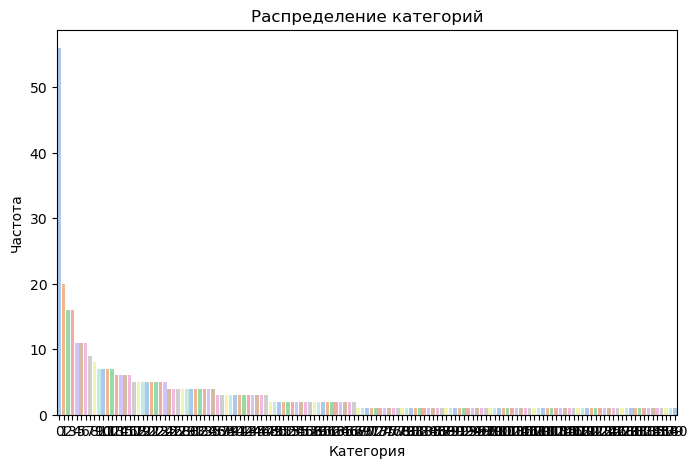

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x=range(len(value_counts.index)), y=value_counts.values, palette="pastel")
plt.title('Распределение категорий')
plt.xlabel('Категория')
plt.ylabel('Частота')
plt.show()

In [25]:
def pipeline_extract_data_4_url(url: str):
    keywords = extract_keywords(url)
    keywords = keywords_cleaner(keywords)
    keywords = [word for word in keywords if len(word) > 3]
    return " ".join(keywords)

In [26]:
def clear_product_text(text: str):
    words = text.split(" ")
    words = [word for word in words if not word.isnumeric() and len(word) > 3]
    return " ".join(words)

In [27]:
df["url_keywords_cleaned"] = df["url"].apply(pipeline_extract_data_4_url)

In [28]:
df["picture_url_keywords_cleaned"] = df["picture_url"].apply(pipeline_extract_data_4_url)

In [29]:
df["product_text_cleaned"] = df["product_text"].apply(clear_product_text)

In [30]:
df["total_text"] = df["product_text_cleaned"] + df["url_keywords_cleaned"] + df["picture_url_keywords_cleaned"]

In [31]:
df

,url,category,picture_url,product_text,url_keywords_cleaned,picture_url_keywords_cleaned,product_text_cleaned,total_text
0,https://www.tula.bestmebelshop.ru/catalog/stol...,Мебель Столы и стулья,https://www.tula.bestmebelshop.ru/upload/resiz...,Журнальный стол Лава 7 BMS состоит из двух сто...,stoly zhurnalnye zhurnalnyy stol lava,upload resize cache iblock cbedbbbeeaaddad ecf...,Журнальный стол Лава состоит двух столиков раз...,Журнальный стол Лава состоит двух столиков раз...
1,https://www.cian.ru/sale/commercial/312865799/,Недвижимость Коммерческая недвижимость,https://images.cdn-cian.ru/images/ofis-moskva-...,"В продаже последние офисы с мокрой точкой, ряд...",sale commercial,images ofis moskva leningradskiy prospekt,"продаже последние офисы мокрой точкой, рядом с...","продаже последние офисы мокрой точкой, рядом с..."
2,https://www.ukazka.ru/catalog/book-ia-lyublyu-...,Книги и канцелярия Книги,https://www.ukazka.ru/catalog/book-ia-lyublyu-...,"Раскрашивайте радужных единорожек, пироженки и...",book lyublyu raskrashivat edinorozhek,book lyublyu raskrashivat edinorozhek,"Раскрашивайте радужных единорожек, пироженки р...","Раскрашивайте радужных единорожек, пироженки р..."
3,https://doctorhead.ru/product/joel_harrison__s...,Хобби и увлечения Антиквариат и коллекциониров...,https://doctorhead.ru/upload/dev2fun.imagecomp...,Трек-лист: A1 Raindrops In Uncommon Times 9:5...,joel harrison still point turning world,upload devfun imagecompress webp iblock exmsbm...,Трек-лист: Raindrops Uncommon Times 9:52 Reall...,Трек-лист: Raindrops Uncommon Times 9:52 Reall...
4,https://www.spb.bestmebelshop.ru/catalog/komod...,Мебель Мебель для хранения,https://www.spb.bestmebelshop.ru/catalog/komod...,Комод Джелия Вин 1 BMS Комод Джелия Вин 1 BMS ...,komod komod dzheliya,komod komod dzheliya,Комод Джелия Комод Джелия предназначена хранен...,Комод Джелия Комод Джелия предназначена хранен...
...,...,...,...,...,...,...,...,...
438,http://berezkazd.ru/catalog/mega_rasprodazha/o...,Строительство и ремонт Отделочные материалы,https://berezkazd.ru/upload/iblock/024/p6xsznu...,Обои HC71961-14 винил горячего тиснения на фли...,mega rasprodazha oboi vinil goryachego tisneni...,upload iblock pxsznufnnvxlgeskxirvexlerwj ceae...,Обои HC71961-14 винил горячего тиснения флизел...,Обои HC71961-14 винил горячего тиснения флизел...
439,https://apteka.ru/product/biofinity-kontaktnye...,Здоровье Оптика,https://images.apteka.ru/original_8cdc77fe-f64...,"Biofinity контактные линзы плановой замены/-5,...",biofinity kontaktnye linzy planovoj zameny feb...,original cdcfe webp,"Biofinity контактные линзы плановой замены/-5,...","Biofinity контактные линзы плановой замены/-5,..."
440,https://stroki.mts.ru/book/imperator-167255?ut...,Книги и канцелярия Книги,https://storage.yandexcloud.net/str-cnt-pub/st...,История времен самого загадочного императора Р...,book imperator,content ridero textbook cover ridero extralarge,История времен самого загадочного императора Р...,История времен самого загадочного императора Р...
441,https://trumart.ru/item/1798284,Транспорт Автотовары и запчасти Шины и диски,https://trumart.ru/files/photos/big/2566236.webp,,,files photos webp,,files photos webp


In [32]:
X = df["total_text"]

In [35]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["category"])

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [39]:
tfidf = TfidfVectorizer(
    max_features=50,
    stop_words=["english", "russian"]
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [40]:
from dotenv import load_dotenv

In [41]:
load_dotenv(".env")

True

In [42]:
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))

In [43]:
mlflow.set_experiment("Notebook simple product classifier")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1744838855362, experiment_id='1', last_update_time=1744838855362, lifecycle_stage='active', name='Notebook simple product classifier', tags={}>

In [46]:
# Включение автоматического логирования параметров и метрик MLflow
mlflow.autolog()

2025/04/17 22:08:49 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


In [51]:
with mlflow.start_run():
    rf = RandomForestClassifier(n_estimators=100, max_depth=8, max_features=3)
    rf.fit(X_train_tfidf, y_train)
    prediction = rf.predict(X_test_tfidf)

/home/tellowit/.config/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


🏃 View run blushing-bat-312 at: http://localhost:5000/#/experiments/1/runs/38f2d51464bc49e9beace9dd2cadb1d6
🧪 View experiment at: http://localhost:5000/#/experiments/1
